In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "X:/Projects/ML/Assignment-1/Q4/Big Mart Sales Prediction Dataset.csv"
output_file_path = "X:/Projects/ML/Assignment-1/Q4/Processed_Dataset.csv"

In [2]:
dataset = pd.read_csv(file_path)

print("Missing Values in Each Column:")
print(dataset.isnull().sum())

Missing Values in Each Column:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [3]:
miss_col = dataset.columns[dataset.isnull().sum() > 0]
miss_cnts = dataset.isnull().sum()[miss_col]

print("\nThe Dataset Contains Missing Values In The Following Columns:")
for col, cnt in miss_cnts.items():
    print(f"{col} Has {cnt} Missing Values")


The Dataset Contains Missing Values In The Following Columns:
Item_Weight Has 1463 Missing Values
Outlet_Size Has 2410 Missing Values


In [4]:
if 'Item_Weight' in dataset.columns:
    mean= dataset['Item_Weight'].mean()
    median= dataset['Item_Weight'].median()
    std= dataset['Item_Weight'].std()
    
    threshold = 0.1 * std
    diff = abs(mean - median)
    
    if diff <= threshold:
        dataset['Item_Weight'] = dataset['Item_Weight'].fillna(mean)
        print("\n'Item_Weight' Missing Values Imputed Using Mean.")
    else:
        dataset['Item_Weight'] = dataset['Item_Weight'].fillna(median)
        print("\n'Item_Weight' Missing Values Imputed Using Median.")

if 'Outlet_Size' in dataset.columns:
    dataset['Outlet_Size'] = dataset['Outlet_Size'].fillna(dataset['Outlet_Size'].mode()[0])
    print("\n'Outlet_Size' Missing Values Imputed Using Mode.")

print(f"\nMissing Values After Imputation:\n{dataset.isnull().sum()}")


'Item_Weight' Missing Values Imputed Using Mean.

'Outlet_Size' Missing Values Imputed Using Mode.

Missing Values After Imputation:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [5]:
dataset.to_csv(output_file_path, index=False)
print(f"The Processed Dataset Has Been Saved To: {output_file_path}")

The Processed Dataset Has Been Saved To: X:/Projects/ML/Assignment-1/Q4/Processed_Dataset.csv


Some Imputation Methods:
1. Mean Imputation:
    Replaces missing values with the mean of the respective column.
    Suitable for numerical features with a symmetric or nearly symmetric distribution.
2. Median Imputation:
    Replaces missing values with the median of the respective column.
    Robust against outliers, making it suitable for skewed distributions.
3. Mode Imputation:
    Replaces missing values with the most frequent value (mode) in the respective column.
    Used primarily for categorical features or numerical features with repeated values.
4. K-Nearest Neighbors (k-NN) Imputation:
    Fills missing values based on the similarity of neighboring samples.
    Computationally expensive but effective for complex datasets.
5. Regression Imputation:
    Predicts missing values using other features in the dataset as predictors.
    Requires building regression models for each feature with missing data.
6. Random Forest Imputation:
    Similar to regression imputation but uses random forest models.
    Captures non-linear relationships effectively.

For Item_Weight (Numerical Feature):        
Imputation Method: Mean or Median.      
Why?
The mean and median of Item_Weight were calculated.
The difference between the mean and median was compared to a threshold based on the standard deviation (10% of the standard deviation).
If the difference was small (indicating a nearly symmetric distribution), the mean was used.
Otherwise, the median was used

For Outlet_Size (Categorical Feature):      
Imputation Method: Mode.        
Why?
The mode is the most frequent category and is suitable for filling missing values in categorical features.
This ensures consistency and minimizes the introduction of noise.

Explanation of Why These Methods Were Suitable:     
Numerical Feature Imputation (Item_Weight):     
The mean is an appropriate imputation method when the data is symmetrically distributed, as it maintains the central tendency.
When the data is skewed, the median is preferred as it is less influenced by outliers, ensuring more accurate imputation.

Categorical Feature Imputation (Outlet_Size):       
The mode captures the most common category, which is a logical replacement for missing values in categorical data.
Other methods, such as k-NN or regression, are unnecessary for this simple case and may overcomplicate the imputation process.

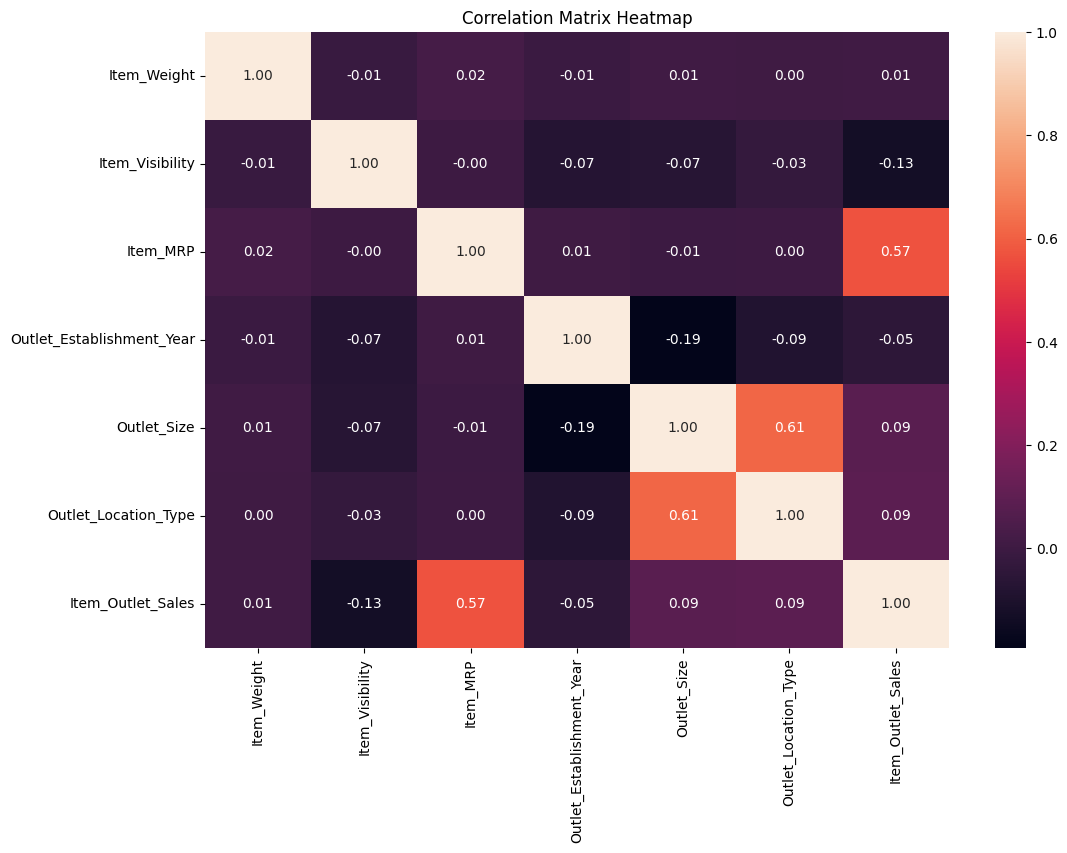

In [6]:
dataset_mat = dataset.drop(columns=['Item_Identifier', 'Item_Type', 'Outlet_Identifier', 'Item_Fat_Content', 'Outlet_Type'])

if 'Outlet_Location_Type' in dataset_mat.columns:
    loc_map = {'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3}
    dataset_mat['Outlet_Location_Type'] = dataset_mat['Outlet_Location_Type'].map(loc_map)
    
if 'Outlet_Size' in dataset_mat.columns:
    size_map = {'Small': 1, 'Medium': 2, 'High': 3}
    dataset_mat['Outlet_Size'] = dataset_mat['Outlet_Size'].map(size_map)

corr_mat = dataset_mat.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


Numerical Features: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']


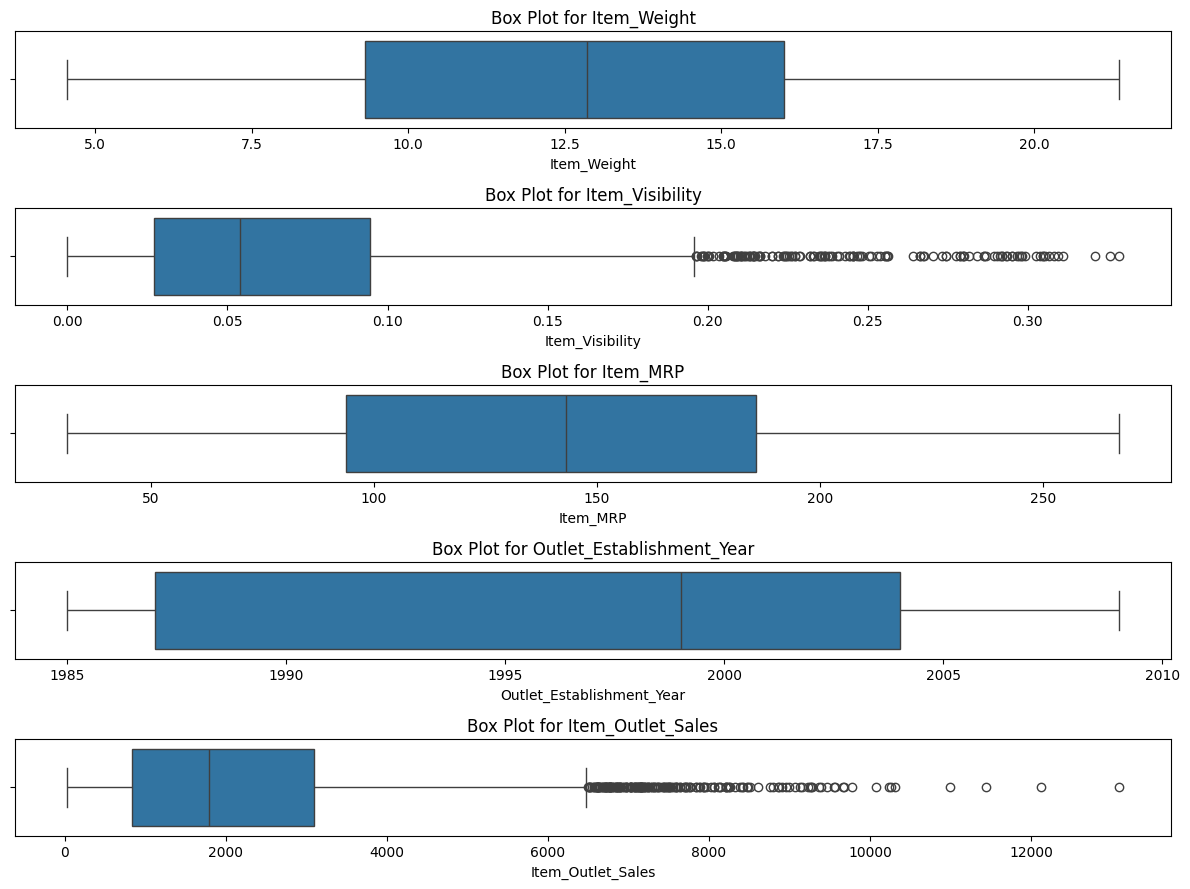

In [7]:
num_feat = dataset.select_dtypes(include=['float64', 'int64']).columns
print(f"\nNumerical Features: {[i for i in num_feat]}")

plt.figure(figsize=(12, 9))
for i, col in enumerate(num_feat, 1):
    plt.subplot(len(num_feat), 1, i)
    sns.boxplot(x=dataset[col])
    plt.title(f"Box Plot for {col}", fontsize=12)
    plt.tight_layout()
plt.show()


Categorical Features: ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


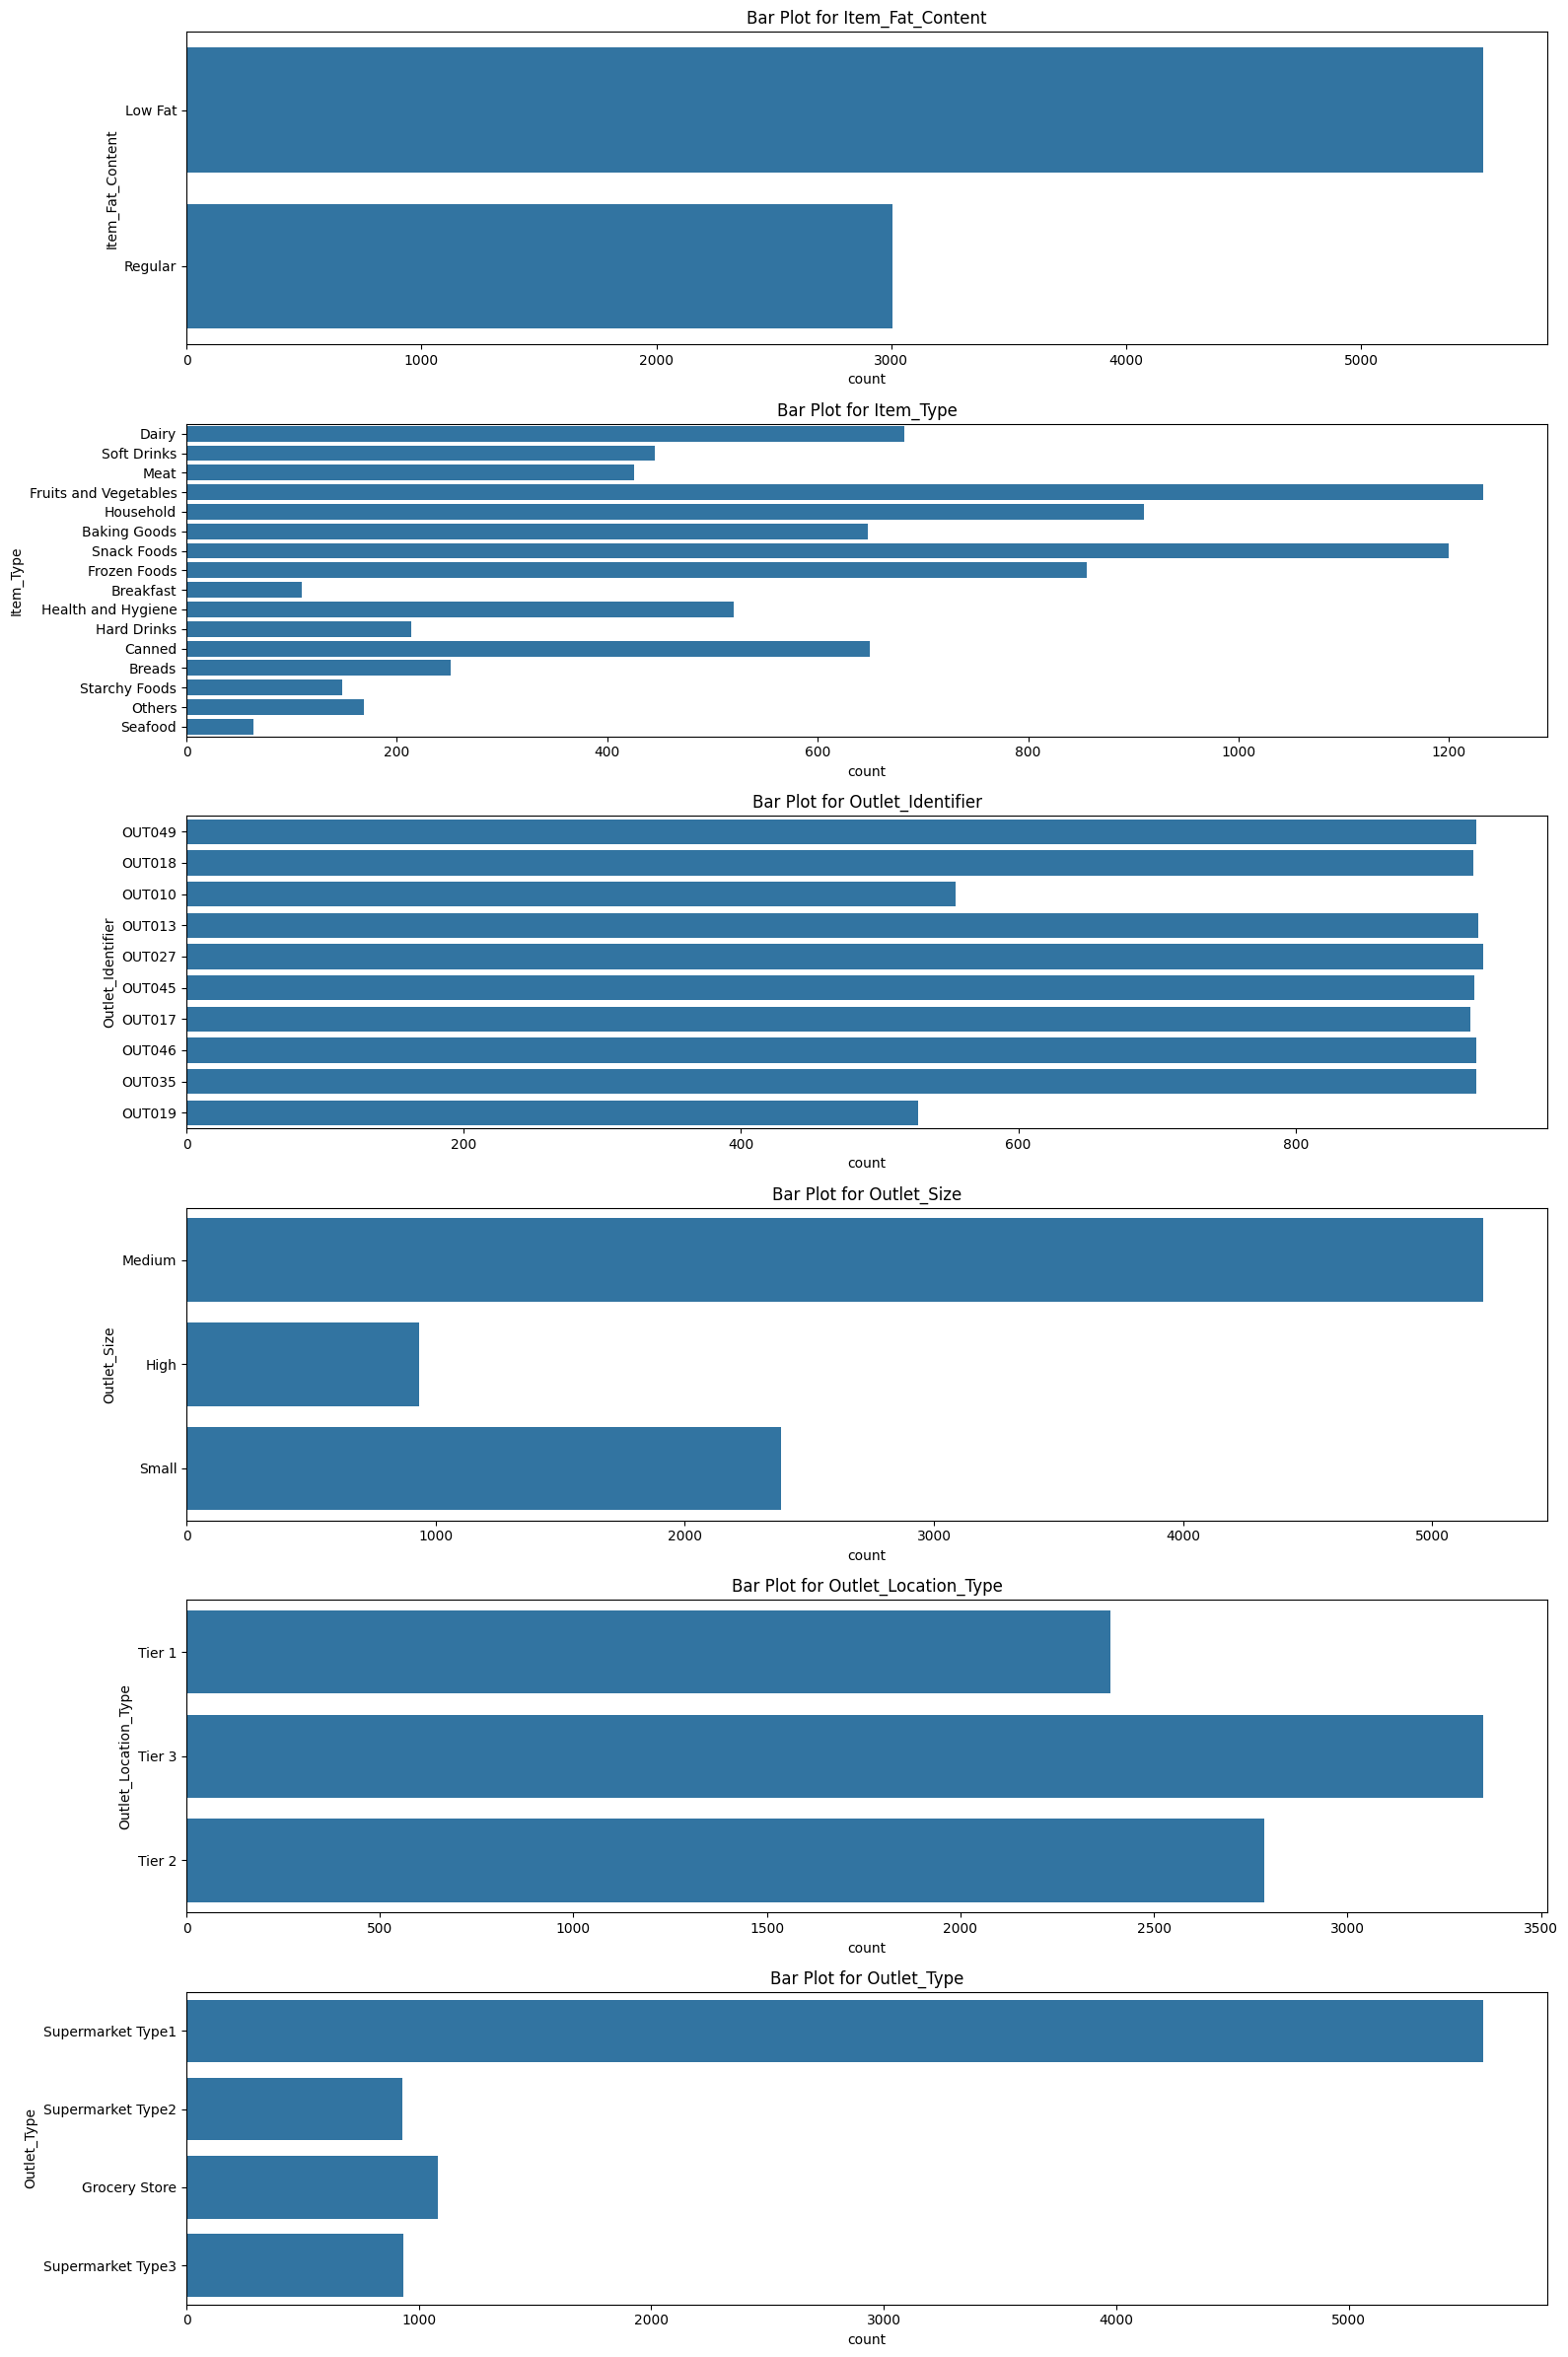

In [8]:
cat_feat= dataset.select_dtypes(include=['object']).columns.drop('Item_Identifier')
print(f"\nCategorical Features: {[i for i in cat_feat]}")

if 'Item_Fat_Content' in dataset.columns:
    dataset['Item_Fat_Content'] = dataset['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

plt.figure(figsize=(16, 24))
for i, col in enumerate(cat_feat, 1):
    plt.subplot(len(cat_feat), 1, i)
    sns.countplot(y=dataset[col])
    plt.title(f"Bar Plot for {col}", fontsize=12)
    plt.tight_layout()
plt.show()

Machine Learning Methods for the Big Mart Sales Prediction Problem:

1. k-Nearest Neighbors (k-NN): 
    A non-parametric algorithm that predicts the target value based on the average of the nearest neighbors.
    Can perform well with proper feature scaling but may struggle with large datasets.
2. Linear Regression: 
    A simple model that assumes a linear relationship between the features and the target variable.
    Can be used as a baseline for comparison with more complex models.
3. Decision Trees:
    A non-linear model that splits the data into subsets based on feature values.
    Handles both numerical and categorical features effectively without requiring much preprocessing.
4. Random Forest:
    An ensemble method based on decision trees.
    Helps reduce overfitting by averaging the predictions of multiple trees.
    Performs well for both regression and classification problems.
5. Support Vector Regression (SVR):
    A non-linear regression method that uses kernel functions to map inputs into higher-dimensional spaces.
    Useful when the relationship between features and the target is non-linear.
6. Neural Networks: 
    Deep learning models can capture complex relationships between input features and the target variable.
    Requires significant preprocessing and tuning but may yield high accuracy for large datasets.